In [4]:
import numpy as np
import pandas as pd
df = pd.read_csv('data/question_4_data.csv')

In [5]:
df.head(8)

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45


4.a.

In [6]:
print("Shape:", df.shape)
print("\nTypes:")
print(df.dtypes)
print("\nNULL elements:\n", df.isnull().sum())


Shape: (1030, 9)

Types:
cement              float64
slag                float64
flyash              float64
water               float64
superplasticizer    float64
coarseaggregate     float64
fineaggregate       float64
age                   int64
csMPa               float64
dtype: object

NULL elements:
 cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64


In [7]:
print(df.describe())

            cement         slag       flyash        water  superplasticizer  \
count  1030.000000  1030.000000  1030.000000  1030.000000       1030.000000   
mean    281.167864    73.895825    54.188350   181.567282          6.204660   
std     104.506364    86.279342    63.997004    21.354219          5.973841   
min     102.000000     0.000000     0.000000   121.800000          0.000000   
25%     192.375000     0.000000     0.000000   164.900000          0.000000   
50%     272.900000    22.000000     0.000000   185.000000          6.400000   
75%     350.000000   142.950000   118.300000   192.000000         10.200000   
max     540.000000   359.400000   200.100000   247.000000         32.200000   

       coarseaggregate  fineaggregate          age        csMPa  
count      1030.000000    1030.000000  1030.000000  1030.000000  
mean        972.918932     773.580485    45.662136    35.817961  
std          77.753954      80.175980    63.169912    16.705742  
min         801.000000  

There are 1030 samples and no null elements in any of the columns. There are 9 featues. 

4.1.II

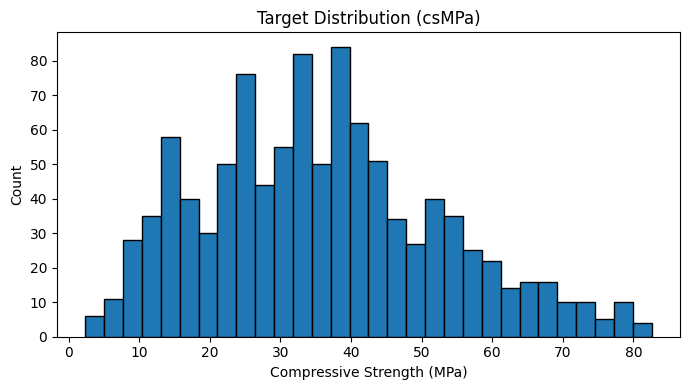

Mean: 35.82 MPa,  Std: 16.71 MPa
Right-skewed: most values cluster 20-50 MPa with a tail toward higher strengths.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# (ii) Target distribution
y = df['csMPa']
plt.figure(figsize=(7, 4))
plt.hist(y, bins=30, edgecolor='black')
plt.xlabel('Compressive Strength (MPa)')
plt.ylabel('Count')
plt.title('Target Distribution (csMPa)')
plt.tight_layout()
plt.show()
print(f'Mean: {y.mean():.2f} MPa,  Std: {y.std():.2f} MPa')
print('Right-skewed: most values cluster 20-50 MPa with a tail toward higher strengths.')

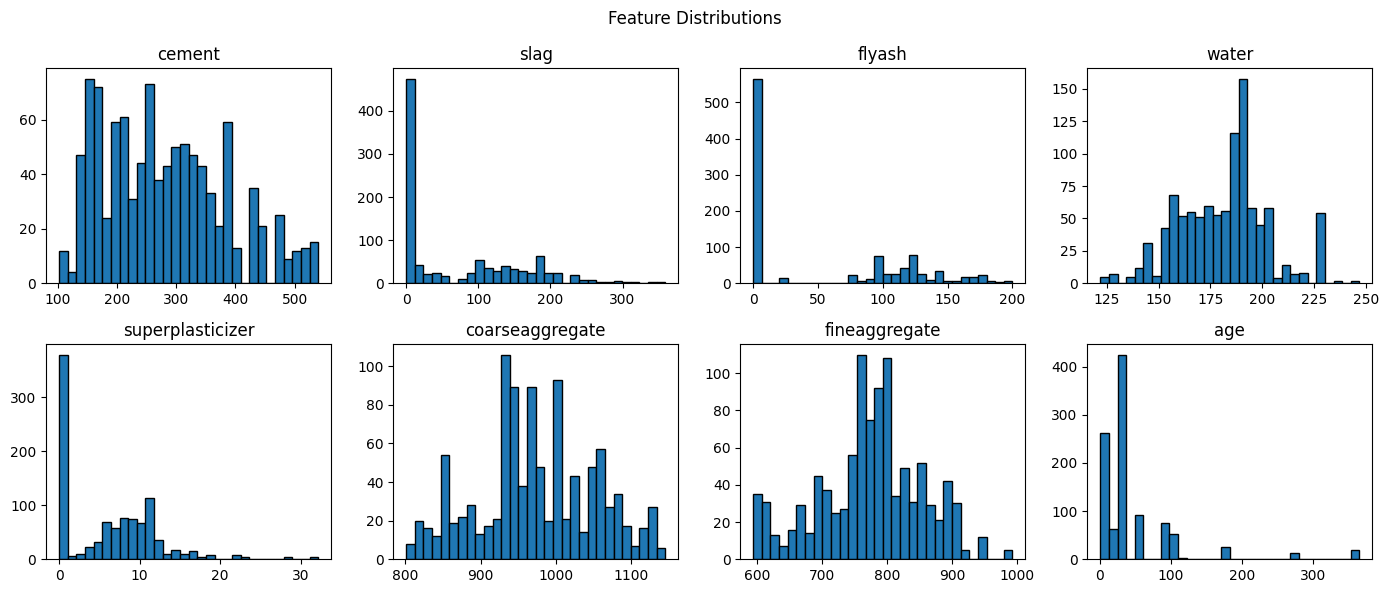

slag and flyash spike at zero: absent from many mixtures.
age is right-skewed: most samples cured 28 days.


In [9]:
# (iii) Feature distributions (2x4 grid)
features = df.columns[:-1].tolist()
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, feat in zip(axes.flatten(), features):
    ax.hist(df[feat], bins=30, edgecolor='black')
    ax.set_title(feat)
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()
print('slag and flyash spike at zero: absent from many mixtures.')
print('age is right-skewed: most samples cured 28 days.')

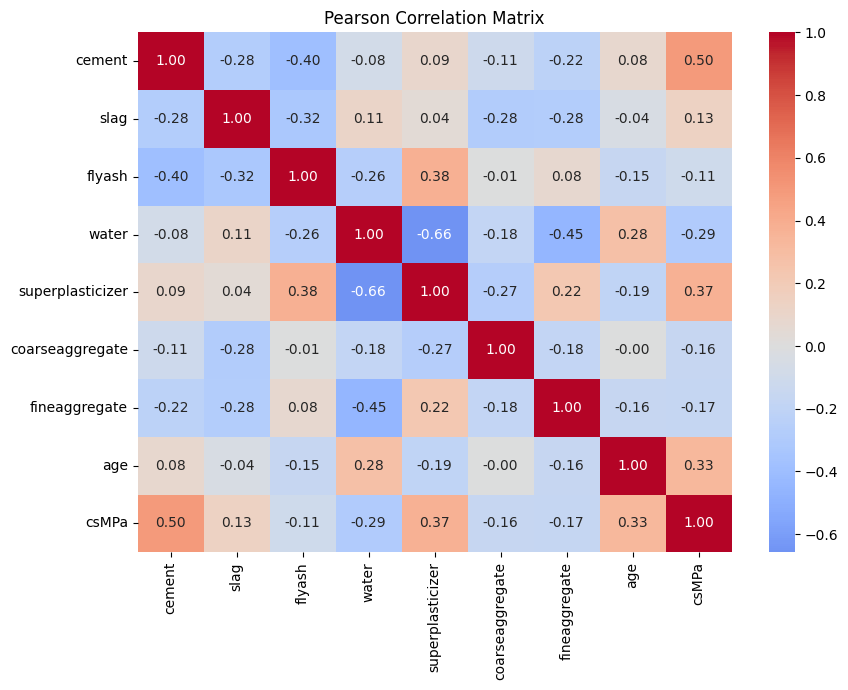

Most negatively correlated: water (-0.29)
Most positively correlated: cement (0.50)
cement/age positively correlated: more cement + longer curing -> stronger concrete.
water negatively correlated: excess water dilutes the cement paste.


In [10]:
# (iv) Pearson correlation heatmap
corr = df.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()
target_corr = corr['csMPa'].drop('csMPa').sort_values()
print(f'Most negatively correlated: {target_corr.idxmin()} ({target_corr.min():.2f})')
print(f'Most positively correlated: {target_corr.idxmax()} ({target_corr.max():.2f})')
print('cement/age positively correlated: more cement + longer curing -> stronger concrete.')
print('water negatively correlated: excess water dilutes the cement paste.')

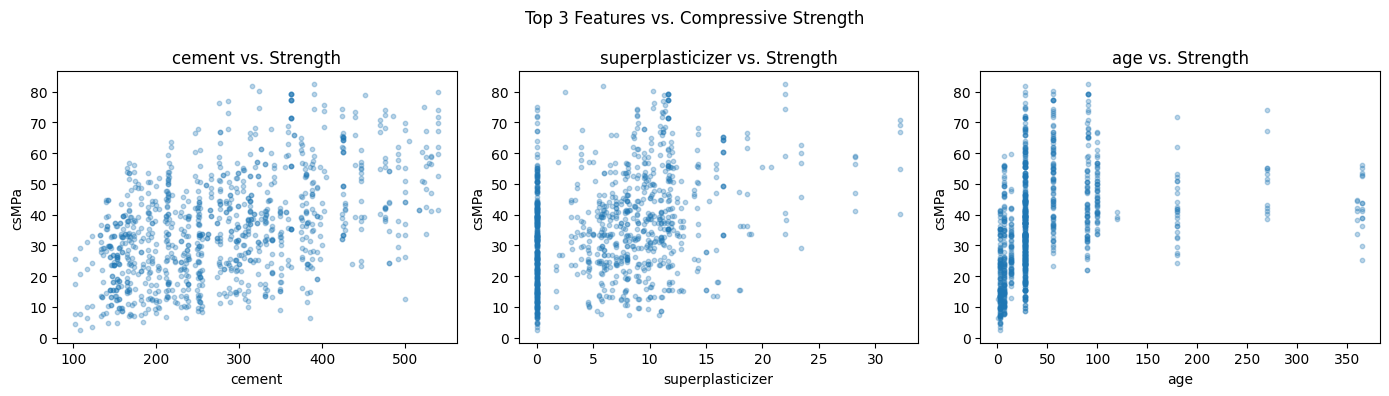

Top 3: ['cement', 'superplasticizer', 'age']
Relationships appear nonlinear/curved


In [11]:
# (v) Scatter plots of top-3 correlated features vs target
top3 = corr['csMPa'].drop('csMPa').abs().nlargest(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, top3):
    ax.scatter(df[feat], df['csMPa'], alpha=0.3, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('csMPa')
    ax.set_title(f'{feat} vs. Strength')
plt.suptitle('Top 3 Features vs. Compressive Strength')
plt.tight_layout()
plt.show()
print(f'Top 3: {top3}')
print('Relationships appear nonlinear/curved')

4.b.

In [12]:
# (i) Train/test split
np.random.seed(42)
X = df.drop(columns='csMPa').values
y = df['csMPa'].values
N = len(X)
idx = np.random.permutation(N)
split = int(0.8 * N)
train_idx, test_idx = idx[:split], idx[split:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
print(f'Train: {len(X_train)} samples,  Test: {len(X_test)} samples')

Train: 824 samples,  Test: 206 samples


In [13]:

# (ii) Why standardize
print("""
Why standardize:
  Cement is in hundreds of kg/m^3 while Superplasticizer is below 30 and Age is 1-365 days.
  Fitting directly on raw features means learned weights must compensate for scale
  differences rather than reflecting true feature importance, making them hard to
  interpret. Standardization (z-score) maps every feature to mean=0, std=1 so weights
  are directly comparable and gradient descent converges faster.""")


Why standardize:
  Cement is in hundreds of kg/m^3 while Superplasticizer is below 30 and Age is 1-365 days.
  Fitting directly on raw features means learned weights must compensate for scale
  differences rather than reflecting true feature importance, making them hard to
  interpret. Standardization (z-score) maps every feature to mean=0, std=1 so weights
  are directly comparable and gradient descent converges faster.


In [14]:

# (iii) Implement standardization (training stats only)
mu    = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
X_train_std = (X_train - mu) / sigma
X_test_std  = (X_test  - mu) / sigma
print('Using training-set mu/sigma on test set to prevent data leakage.')

Using training-set mu/sigma on test set to prevent data leakage.


In [15]:
# (iv) Verify
print('Train mean (~0):', X_train_std.mean(axis=0).round(4))
print('Train std  (~1):', X_train_std.std(axis=0).round(4))
print('Test mean (close to 0):', X_test_std.mean(axis=0).round(4))
print('Test std  (close to 1):', X_test_std.std(axis=0).round(4))
print('Test stats differ from exactly 0/1 because we used training-set statistics,'
      ' not test-set statistics, to avoid data leakage.')

Train mean (~0): [0. 0. 0. 0. 0. 0. 0. 0.]
Train std  (~1): [1. 1. 1. 1. 1. 1. 1. 1.]
Test mean (close to 0): [ 0.0505  0.0824 -0.0593  0.1463 -0.1321  0.0373 -0.1887  0.0291]
Test std  (close to 1): [1.0452 1.1202 0.9925 0.9218 0.894  0.9295 0.9302 0.9496]
Test stats differ from exactly 0/1 because we used training-set statistics, not test-set statistics, to avoid data leakage.


4.c.

In [16]:
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# OLS normal equations: w* = (X^T X)^{-1} X^T y
Xb_train = add_bias(X_train_std)
Xb_test  = add_bias(X_test_std)
w_ols = np.linalg.solve(Xb_train.T @ Xb_train, Xb_train.T @ y_train)

# (i) MSE
ols_train_mse = mse(y_train, Xb_train @ w_ols)
ols_test_mse  = mse(y_test,  Xb_test  @ w_ols)
print(f'OLS  Train MSE: {ols_train_mse:.2f}')
print(f'OLS  Test  MSE: {ols_test_mse:.2f}')

OLS  Train MSE: 107.79
OLS  Test  MSE: 106.86


In [17]:
# (ii) Largest absolute weight (weights are comparable because features are standardized)
feature_names = df.columns[:-1].tolist()
weights = w_ols[1:]
largest_idx = int(np.argmax(np.abs(weights)))
print(f'Largest |weight|: {feature_names[largest_idx]} ({weights[largest_idx]:.4f})')
print('cement typically has the largest weight - it is the primary binder in concrete'
      ' and has the strongest correlation with compressive strength.')

Largest |weight|: cement (13.2180)
cement typically has the largest weight - it is the primary binder in concrete and has the strongest correlation with compressive strength.


4.d.

In [18]:
from itertools import combinations_with_replacement
from math import comb

def poly_features(X, degree):
    n, d = X.shape
    cols = [np.ones(n)]
    for j in range(d):
        cols.append(X[:, j])
    if degree >= 2:
        for i, j in combinations_with_replacement(range(d), 2):
            cols.append(X[:, i] * X[:, j])
    if degree >= 3:
        for i, j, k in combinations_with_replacement(range(d), 3):
            cols.append(X[:, i] * X[:, j] * X[:, k])
    return np.column_stack(cols)

# (i) Feature counts: C(d+p, p)
d = 8
for p in [2, 3]:
    print(f'p={p}: {comb(d+p, p)} features (including bias)')

# (ii) Degree-2
Xp2_train = poly_features(X_train_std, 2)
Xp2_test  = poly_features(X_test_std,  2)
w_p2 = np.linalg.solve(Xp2_train.T @ Xp2_train, Xp2_train.T @ y_train)
p2_train_mse = mse(y_train, Xp2_train @ w_p2)
p2_test_mse  = mse(y_test,  Xp2_test  @ w_p2)
print(f'Degree-2  Train MSE: {p2_train_mse:.2f}')
print(f'Degree-2  Test  MSE: {p2_test_mse:.2f}')
print('Degree-2 should improve on OLS as squared terms capture nonlinear relationships.')

# (iii) Degree-3
Xp3_train = poly_features(X_train_std, 3)
Xp3_test  = poly_features(X_test_std,  3)
w_p3 = np.linalg.solve(Xp3_train.T @ Xp3_train, Xp3_train.T @ y_train)
p3_train_mse = mse(y_train, Xp3_train @ w_p3)
p3_test_mse  = mse(y_test,  Xp3_test  @ w_p3)
print(f'Degree-3  Train MSE: {p3_train_mse:.2f}')
print(f'Degree-3  Test  MSE: {p3_test_mse:.2f}')
print('Training MSE drops but test MSE likely increases vs degree-2: overfitting.'
      ' C(11,3)=165 features with only ~824 training samples.')

p=2: 45 features (including bias)
p=3: 165 features (including bias)
Degree-2  Train MSE: 51.91
Degree-2  Test  MSE: 59.68
Degree-2 should improve on OLS as squared terms capture nonlinear relationships.
Degree-3  Train MSE: 19.72
Degree-3  Test  MSE: 35.61
Training MSE drops but test MSE likely increases vs degree-2: overfitting. C(11,3)=165 features with only ~824 training samples.


4.e.

lambda        Train MSE     Test MSE
------------------------------------
0.0001            19.72        35.56
0.001             19.73        35.21
0.01              19.84        34.10
0.1               20.19        33.57
1                 21.38        33.84
10                29.13        43.23
100               74.71        88.84


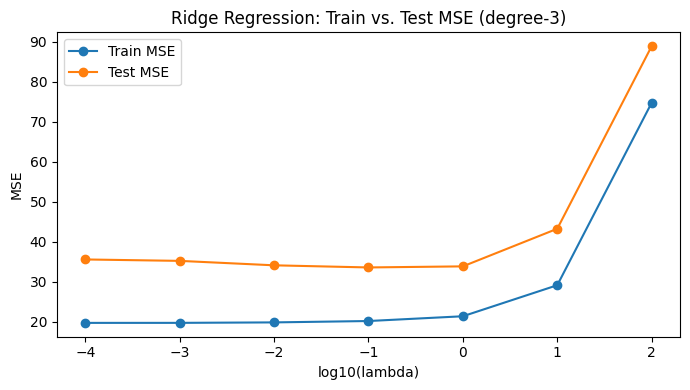

Best lambda=0.1  Train MSE=20.19  Test MSE=33.57
Unregularized degree-3 test MSE: 35.61  -> ridge fixes overfitting.
Linear OLS test MSE:             106.86  -> poly+ridge beats plain linear.
Bias-variance tradeoff: too small lambda = overfitting; too large = underfitting.


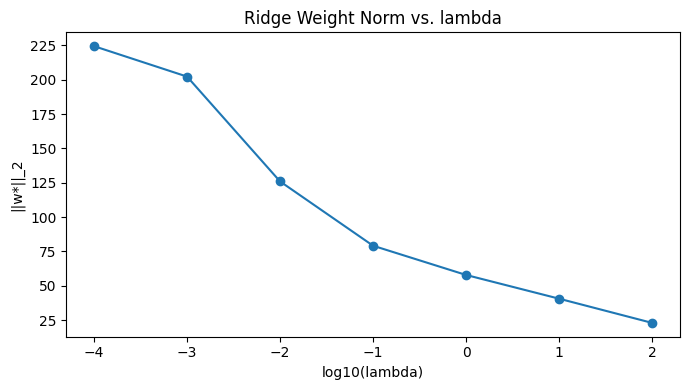

Weights shrink toward zero as lambda increases.
From Problem 3: ridge = augmented LS with d fake zero-target rows, pulling weights to zero.


In [20]:
def ridge_fit(X, y, lam):
    d = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(d), X.T @ y)

lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]

# (i) Sweep lambda
ridge_results = []
print(f"{'lambda':<10} {'Train MSE':>12} {'Test MSE':>12}")
print('-' * 36)
for lam in lambdas:
    w = ridge_fit(Xp3_train, y_train, lam)
    tr = mse(y_train, Xp3_train @ w)
    te = mse(y_test,  Xp3_test  @ w)
    ridge_results.append((lam, tr, te, w))
    print(f'{lam:<10} {tr:>12.2f} {te:>12.2f}')

# (ii) Plot train vs test MSE
log_lams     = [np.log10(r[0]) for r in ridge_results]
train_mses_r = [r[1] for r in ridge_results]
test_mses_r  = [r[2] for r in ridge_results]
plt.figure(figsize=(7, 4))
plt.plot(log_lams, train_mses_r, marker='o', label='Train MSE')
plt.plot(log_lams, test_mses_r,  marker='o', label='Test MSE')
plt.xlabel('log10(lambda)')
plt.ylabel('MSE')
plt.title('Ridge Regression: Train vs. Test MSE (degree-3)')
plt.legend()
plt.tight_layout()
plt.show()

# (iii) Best lambda and comparison
best = min(ridge_results, key=lambda r: r[2])
print(f'Best lambda={best[0]}  Train MSE={best[1]:.2f}  Test MSE={best[2]:.2f}')
print(f'Unregularized degree-3 test MSE: {p3_test_mse:.2f}  -> ridge fixes overfitting.')
print(f'Linear OLS test MSE:             {ols_test_mse:.2f}  -> poly+ridge beats plain linear.')
print('Bias-variance tradeoff: too small lambda = overfitting; too large = underfitting.')

# (iv) Weight norm vs lambda
norms = [np.linalg.norm(r[3]) for r in ridge_results]
plt.figure(figsize=(7, 4))
plt.plot(log_lams, norms, marker='o')
plt.xlabel('log10(lambda)')
plt.ylabel('||w*||_2')
plt.title('Ridge Weight Norm vs. lambda')
plt.tight_layout()
plt.show()
print('Weights shrink toward zero as lambda increases.')
print('From Problem 3: ridge = augmented LS with d fake zero-target rows, pulling weights to zero.')

4.f.

In [21]:
# (i) 5-fold CV on training data
def kfold_cv(X, y, lambdas, k=5):
    n = len(y)
    fold_size = n // k
    cv_mses = {lam: [] for lam in lambdas}
    for fold in range(k):
        val_idx = np.arange(fold * fold_size, (fold + 1) * fold_size)
        tr_idx  = np.concatenate([np.arange(0, fold * fold_size),
                                   np.arange((fold + 1) * fold_size, n)])
        Xtr, ytr = X[tr_idx], y[tr_idx]
        Xvl, yvl = X[val_idx], y[val_idx]
        for lam in lambdas:
            w = ridge_fit(Xtr, ytr, lam)
            cv_mses[lam].append(mse(yvl, Xvl @ w))
    return {lam: np.mean(v) for lam, v in cv_mses.items()}

cv_results = kfold_cv(Xp3_train, y_train, lambdas)
print(f"{'lambda':<10} {'Mean Val MSE':>14}")
print('-' * 26)
for lam, val_mse_val in cv_results.items():
    print(f'{lam:<10} {val_mse_val:>14.2f}')

# (ii) Best lambda and final test result
best_lam_cv = min(cv_results, key=cv_results.get)
w_final = ridge_fit(Xp3_train, y_train, best_lam_cv)
final_test_mse = mse(y_test, Xp3_test @ w_final)
print(f'Best lambda from 5-fold CV: {best_lam_cv}')
print(f'Final Test MSE (CV-selected lambda): {final_test_mse:.2f}')
print(f'Single-split best test MSE: {min(r[2] for r in ridge_results):.2f}')
print('CV and single-split conclusions should be similar; CV is more stable.')

# (iii) Why not use test set in CV
print("""
Why not use the test set inside CV:
  Using test-set performance to choose lambda contaminates it - it no longer represents
  unseen data and any reported test MSE becomes optimistically biased. We would effectively
  be tuning to the test set. CV uses only training data so the test set remains a clean
  estimate of true generalization performance.""")

lambda       Mean Val MSE
--------------------------
0.0001              47.97
0.001               47.68
0.01                46.62
0.1                 44.21
1                   41.47
10                  49.61
100                103.91
Best lambda from 5-fold CV: 1
Final Test MSE (CV-selected lambda): 33.84
Single-split best test MSE: 33.57
CV and single-split conclusions should be similar; CV is more stable.

Why not use the test set inside CV:
  Using test-set performance to choose lambda contaminates it - it no longer represents
  unseen data and any reported test MSE becomes optimistically biased. We would effectively
  be tuning to the test set. CV uses only training data so the test set remains a clean
  estimate of true generalization performance.


4.g.

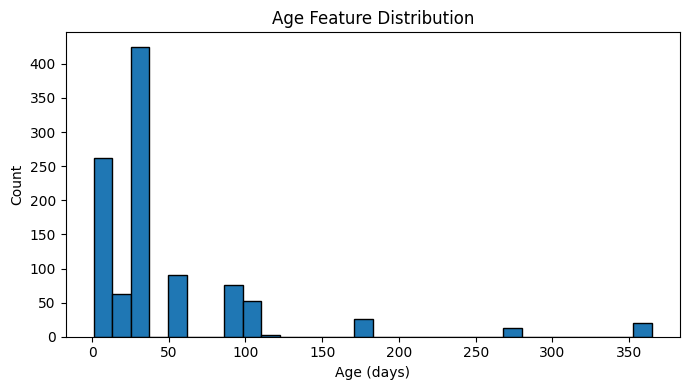

Distinct age values: 14
Fraction with Age=28: 0.413
Heavily right-skewed with a dominant spike at 28 days (industry-standard curing time).
WLS  Train MSE: 127.82
WLS  Test  MSE: 125.21
OLS  Train MSE: 107.79
OLS  Test  MSE: 106.86
WLS may have higher overall MSE but gives fairer predictions across all age groups. A practitioner might prefer it for safety-critical early/late-age predictions.


In [22]:
# (i) Age histogram
plt.figure(figsize=(7, 4))
plt.hist(df['age'], bins=30, edgecolor='black')
plt.xlabel('Age (days)')
plt.ylabel('Count')
plt.title('Age Feature Distribution')
plt.tight_layout()
plt.show()
distinct_ages = df['age'].nunique()
frac_28 = (df['age'] == 28).mean()
print(f'Distinct age values: {distinct_ages}')
print(f'Fraction with Age=28: {frac_28:.3f}')
print('Heavily right-skewed with a dominant spike at 28 days (industry-standard curing time).')

# (ii) Weighted least squares with inverse-frequency weights
age_counts = df['age'].value_counts().to_dict()
N_total = len(df)
alphas_all = np.array([N_total / age_counts[df['age'].iloc[i]] for i in range(N_total)])
alphas = alphas_all[train_idx]

A = np.diag(alphas)
w_wls = np.linalg.solve(Xb_train.T @ A @ Xb_train, Xb_train.T @ A @ y_train)
wls_train_mse = mse(y_train, Xb_train @ w_wls)
wls_test_mse  = mse(y_test,  Xb_test  @ w_wls)
print(f'WLS  Train MSE: {wls_train_mse:.2f}')
print(f'WLS  Test  MSE: {wls_test_mse:.2f}')
print(f'OLS  Train MSE: {ols_train_mse:.2f}')
print(f'OLS  Test  MSE: {ols_test_mse:.2f}')
print('WLS may have higher overall MSE but gives fairer predictions across all age groups.'
      ' A practitioner might prefer it for safety-critical early/late-age predictions.')

4.h.

In [23]:
best_ridge_w = ridge_fit(Xp3_train, y_train, best_lam_cv)

models = [
    ('Linear OLS',            mse(y_train, Xb_train  @ w_ols),       mse(y_test, Xb_test  @ w_ols)),
    ('Degree-2 polynomial',   mse(y_train, Xp2_train @ w_p2),        mse(y_test, Xp2_test @ w_p2)),
    ('Degree-3 polynomial',   mse(y_train, Xp3_train @ w_p3),        mse(y_test, Xp3_test @ w_p3)),
    (f'Ridge deg-3 (lam={best_lam_cv})', mse(y_train, Xp3_train @ best_ridge_w), mse(y_test, Xp3_test @ best_ridge_w)),
    ('Weighted Linear (WLS)', wls_train_mse,                          wls_test_mse),
]
print(f"{'Model':<35} {'Train MSE':>12} {'Test MSE':>12}")
print('-' * 61)
for name, tr, te in models:
    print(f'{name:<35} {tr:>12.2f} {te:>12.2f}')

print("""
Discussion:
  1. Recommended model: Ridge regression on degree-3 polynomial features.
     It achieves the lowest test MSE by capturing nonlinear ingredient interactions
     while regularization prevents overfitting.

  2. Role of regularization: Without it, degree-3 features drastically overfit
     (~165 parameters, ~824 training samples). Ridge shrinks weights toward zero,
     reducing variance at a small bias cost, yielding much better generalization.

  3. When to prefer WLS: When reliable predictions are needed across ALL age groups.
     Despite higher overall MSE, WLS corrects for sampling imbalance (over-representation
     of 28-day samples). For safety-critical early-age or late-age predictions this
     fairness is worth the small accuracy tradeoff.""")

Model                                  Train MSE     Test MSE
-------------------------------------------------------------
Linear OLS                                107.79       106.86
Degree-2 polynomial                        51.91        59.68
Degree-3 polynomial                        19.72        35.61
Ridge deg-3 (lam=1)                        21.38        33.84
Weighted Linear (WLS)                     127.82       125.21

Discussion:
  1. Recommended model: Ridge regression on degree-3 polynomial features.
     It achieves the lowest test MSE by capturing nonlinear ingredient interactions
     while regularization prevents overfitting.

  2. Role of regularization: Without it, degree-3 features drastically overfit
     (~165 parameters, ~824 training samples). Ridge shrinks weights toward zero,
     reducing variance at a small bias cost, yielding much better generalization.

  3. When to prefer WLS: When reliable predictions are needed across ALL age groups.
     Despite high